In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import ast
import os
import random
import time
import requests
import re
import nltk
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from collections import Counter
import requests
import os
import re
import time
import random
from PIL import Image
from io import BytesIO
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torchvision import transforms
from sklearn.preprocessing import MultiLabelBinarizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

import warnings



Using device: cuda


In [ ]:
data="/content/drive/MyDrive/movie_recommendation/tmdb_cleaned.csv"
df=pd.read_csv(data)
df.head(3)


,title,overview,genres,poster_path,Action,Adventure,Animation,Comedy,Crime,Documentary,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,sample_weight
0,Shadows in Paradise,"Nikander, a rubbish collector and would-be ent...","['Comedy', 'Drama', 'Romance']",nj01hspawPof0mJmlgfjuLyJuRN.jpg,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0.000137
1,Judgment Night,"Four young friends, while taking a shortcut en...","['Action', 'Crime', 'Thriller']",3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0.000251
2,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...","['Animation', 'Family']",eHuGQ10FUzK1mdOY69wF5pGgEf5.jpg,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0.000519


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30016 entries, 0 to 30015
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            30016 non-null  object 
 1   overview         30016 non-null  object 
 2   genres           30016 non-null  object 
 3   poster_path      30016 non-null  object 
 4   Action           30016 non-null  int64  
 5   Adventure        30016 non-null  int64  
 6   Animation        30016 non-null  int64  
 7   Comedy           30016 non-null  int64  
 8   Crime            30016 non-null  int64  
 9   Documentary      30016 non-null  int64  
 10  Drama            30016 non-null  int64  
 11  Family           30016 non-null  int64  
 12  Fantasy          30016 non-null  int64  
 13  History          30016 non-null  int64  
 14  Horror           30016 non-null  int64  
 15  Music            30016 non-null  int64  
 16  Mystery          30016 non-null  int64  
 17  Romance     

In [ ]:
cols_to_drop = ["adult","belongs_to_collection","imdb_id","poster_path","video","budget", "homepage", "keywords", "original_language", "popularity",
                "production_companies", "production_countries", "release_date",
                "revenue", "runtime", "spoken_languages", "status", "tagline",
                "title", "vote_average", "vote_count"]

existing_cols = [col for col in cols_to_drop if col in df.columns]
fdf = df.drop(columns=existing_cols)
fdf


,overview,genres,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,sample_weight
0,"Nikander, a rubbish collector and would-be ent...","['Comedy', 'Drama', 'Romance']",0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0.000137
1,"Four young friends, while taking a shortcut en...","['Action', 'Crime', 'Thriller']",1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0.000251
2,"Nemo, an adventurous young clownfish, is unexp...","['Animation', 'Family']",0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0.000519
3,A man with a low IQ has accomplished great thi...,"['Comedy', 'Drama', 'Romance']",0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0.000137
4,Newspaper magnate Charles Foster Kane is taken...,"['Mystery', 'Drama']",0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0.000350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30011,An American's family jewels are stolen during ...,"['Action', 'TV Movie', 'Family', 'Adventure']",1,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0.000476
30012,The fisherman from a Cornish village have a fr...,"['Comedy', 'Drama', 'War', 'Romance']",0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0.000396
30013,Petit Potam lives in the village of Barbotam o...,['Animation'],0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.000576
30014,"In the year 2011, the prison system is run by ...","['Action', 'Science Fiction', 'Thriller']",1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0.000323


In [ ]:
fdf = fdf.applymap(lambda x: str(x) if isinstance(x, (list, dict)) else x)

print(f"Initial shape: {fdf.shape}")
print(f"Number of duplicates: {fdf.duplicated().sum()}")


fdf_clean = fdf.drop_duplicates()

print(f"\nAfter duplicate removal: {fdf_clean.shape}")
print(f"Duplicates remaining: {fdf_clean.duplicated().sum()}")

if fdf.duplicated().sum() > 0:
    print("\nSample duplicate rows:")
    print(fdf[fdf.duplicated(keep=False)].sort_values(by=fdf.columns.tolist()).head(3))

<ipython-input-6-5c1e553f5025>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  fdf = fdf.applymap(lambda x: str(x) if isinstance(x, (list, dict)) else x)


Initial shape: (30016, 22)
Number of duplicates: 620

After duplicate removal: (29396, 22)
Duplicates remaining: 0

Sample duplicate rows:
                                                overview  \
6052   A direct-to-video compilation of the highlight...   
6053   A direct-to-video compilation of the highlight...   
21439  At 56 years of age Mita Pantić (Nikola Simić) ...   

                          genres  Action  Adventure  Animation  Comedy  Crime  \
6052   ['Documentary', 'Horror']       0          0          0       0      0   
6053   ['Documentary', 'Horror']       0          0          0       0      0   
21439                 ['Comedy']       0          0          0       1      0   

       Documentary  Drama  Family  ...  Horror  Music  Mystery  Romance  \
6052             1      0       0  ...       1      0        0        0   
6053             1      0       0  ...       1      0        0        0   
21439            0      0       0  ...       0      0        0        

In [ ]:
fdf.head(10)

,overview,genres,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,sample_weight
0,"Nikander, a rubbish collector and would-be ent...","['Comedy', 'Drama', 'Romance']",0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0.000137
1,"Four young friends, while taking a shortcut en...","['Action', 'Crime', 'Thriller']",1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0.000251
2,"Nemo, an adventurous young clownfish, is unexp...","['Animation', 'Family']",0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0.000519
3,A man with a low IQ has accomplished great thi...,"['Comedy', 'Drama', 'Romance']",0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0.000137
4,Newspaper magnate Charles Foster Kane is taken...,"['Mystery', 'Drama']",0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0.000350
5,"Selma, a Czech immigrant on the verge of blind...","['Drama', 'Crime']",0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0.000194
6,"In 2257, a taxi driver is unintentionally give...","['Science Fiction', 'Action', 'Adventure']",1,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0.000390
7,In a futuristic city sharply divided between t...,"['Drama', 'Science Fiction']",0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0.000302
8,Bruce Brown's The Endless Summer is one of the...,['Documentary'],0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0.000430
9,After Port Royal is attacked and pillaged by a...,"['Adventure', 'Fantasy', 'Action']",1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.000421


In [ ]:
fdf.isnull().sum()

,0
overview,0
genres,0
Action,0
Adventure,0
Animation,0
Comedy,0
Crime,0
Documentary,0
Drama,0
Family,0


In [ ]:
fdf=fdf.dropna(subset=["overview"])
fdf.isnull().sum()

,0
overview,0
genres,0
Action,0
Adventure,0
Animation,0
Comedy,0
Crime,0
Documentary,0
Drama,0
Family,0


In [ ]:
fdf.shape

(30016, 22)

<ipython-input-11-851c735517bb>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(genre_counts.keys()), y=list(genre_counts.values()), palette="viridis")


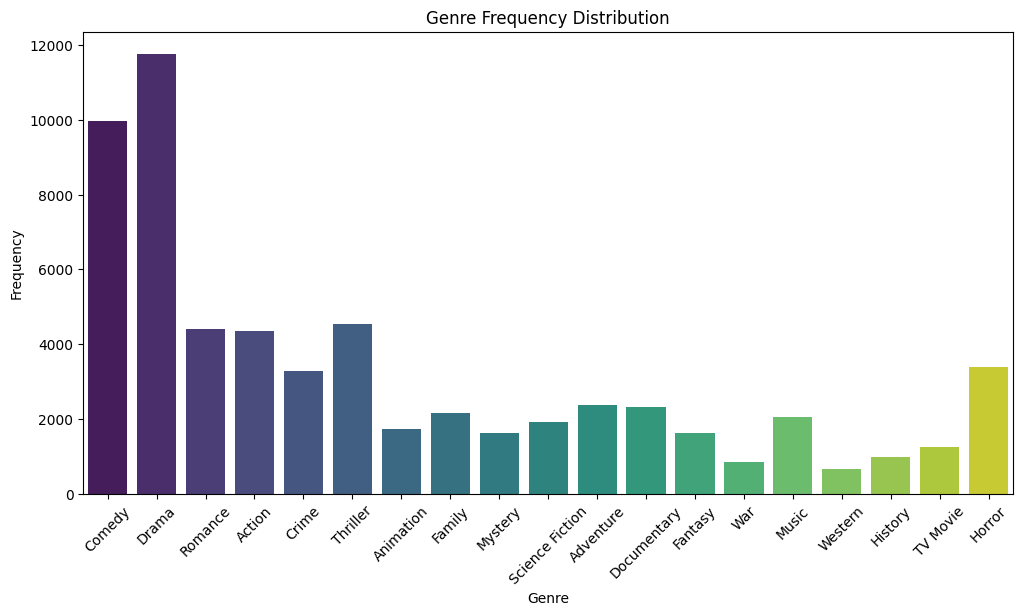

In [ ]:
df['genres'] = df['genres'].apply(lambda x: eval(x) if isinstance(x, str) else x)


all_genres = [genre for sublist in df['genres'].dropna() for genre in sublist]
genre_counts = Counter(all_genres)


plt.figure(figsize=(12, 6))
sns.barplot(x=list(genre_counts.keys()), y=list(genre_counts.values()), palette="viridis")
plt.title("Genre Frequency Distribution")
plt.xlabel("Genre")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

<ipython-input-12-12238d13df22>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combination_counts.head(10).index, y=combination_counts.head(10).values, palette="viridis")


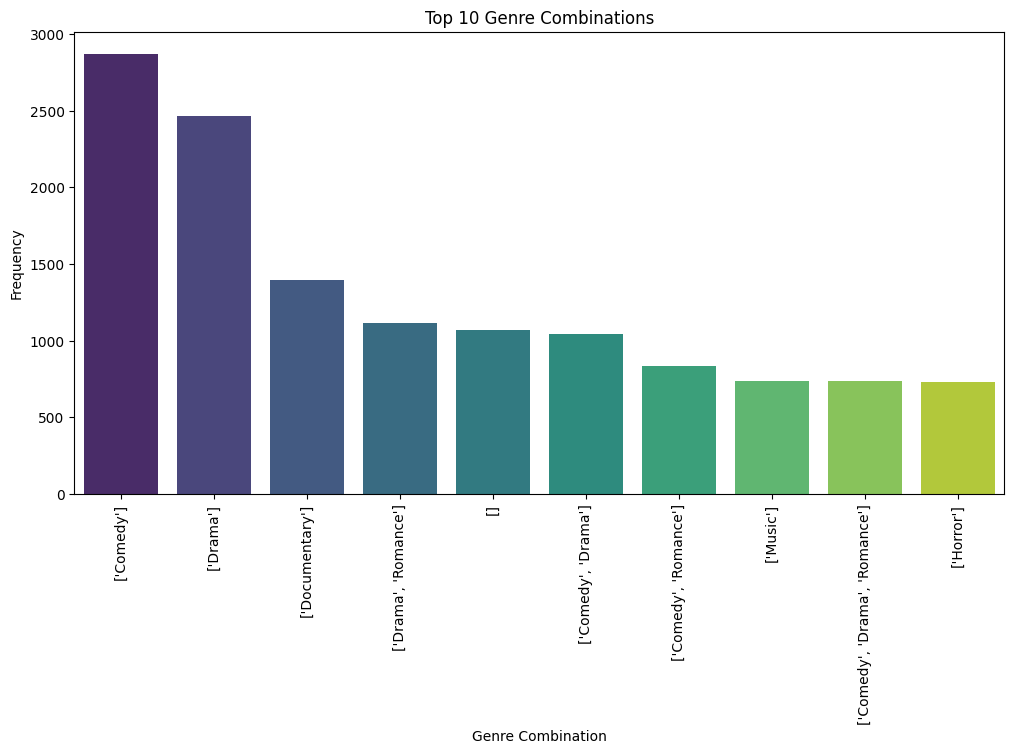

In [ ]:
df['genre_key'] = df['genres'].apply(lambda x: str(sorted(x)) if isinstance(x, list) and len(x) > 0 else '[]')
combination_counts = df['genre_key'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=combination_counts.head(10).index, y=combination_counts.head(10).values, palette="viridis")
plt.title("Top 10 Genre Combinations")
plt.xlabel("Genre Combination")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()


In [ ]:

fdf_cleaned = fdf.dropna()
print(fdf_cleaned.isnull().sum())
print(f"Original DataFrame shape: {fdf.shape}")
print(f"Cleaned DataFrame shape: {fdf_cleaned.shape}")

overview           0
genres             0
Action             0
Adventure          0
Animation          0
Comedy             0
Crime              0
Documentary        0
Drama              0
Family             0
Fantasy            0
History            0
Horror             0
Music              0
Mystery            0
Romance            0
Science Fiction    0
TV Movie           0
Thriller           0
War                0
Western            0
sample_weight      0
dtype: int64
Original DataFrame shape: (30016, 22)
Cleaned DataFrame shape: (30016, 22)


In [ ]:
import warnings
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_text(text):
    if not isinstance(text, str):
        return ''

    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\+?[\d\-\(\) ]{10,}', '', text)
    text = re.sub(r'\d{1,2}[-/]\d{1,2}[-/]\d{2,4}', '', text)
    text = re.sub(r'\d{4}[-/]\d{1,2}[-/]\d{1,2}', '', text)
    text = re.sub(r'\d{1,2}\s+(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\s+\d{2,4}', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)


    words = nltk.word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    words = [word for word in words if len(word) > 1]

    return ' '.join(words)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:

fdf = fdf[fdf['genres'].notna() & (fdf['genres'] != '')]
fdf['overview'] = fdf['overview'].fillna('').apply(preprocess_text)
fdf.head(5)

,overview,genres,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,sample_weight
0,nikander rubbish collector would entrepreneur ...,"['Comedy', 'Drama', 'Romance']",0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0.000137
1,four young friend taking shortcut en route loc...,"['Action', 'Crime', 'Thriller']",1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0.000251
2,nemo adventurous young clownfish unexpectedly ...,"['Animation', 'Family']",0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0.000519
3,man low iq accomplished great thing life prese...,"['Comedy', 'Drama', 'Romance']",0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0.000137
4,newspaper magnate charles foster kane taken mo...,"['Mystery', 'Drama']",0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0.000350


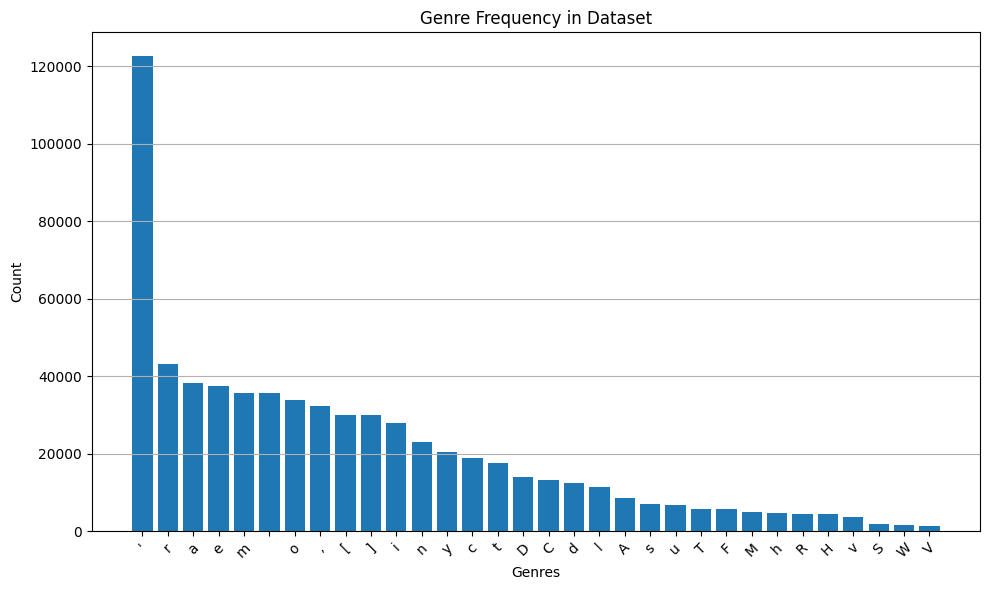

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter




genre_counter = Counter()
fdf['genres'].apply(lambda genres: genre_counter.update(genres))

genre_df = pd.DataFrame(genre_counter.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)


plt.figure(figsize=(10, 6))
plt.bar(genre_df['Genre'], genre_df['Count'])
plt.xlabel('Genres')
plt.ylabel('Count')
plt.title('Genre Frequency in Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


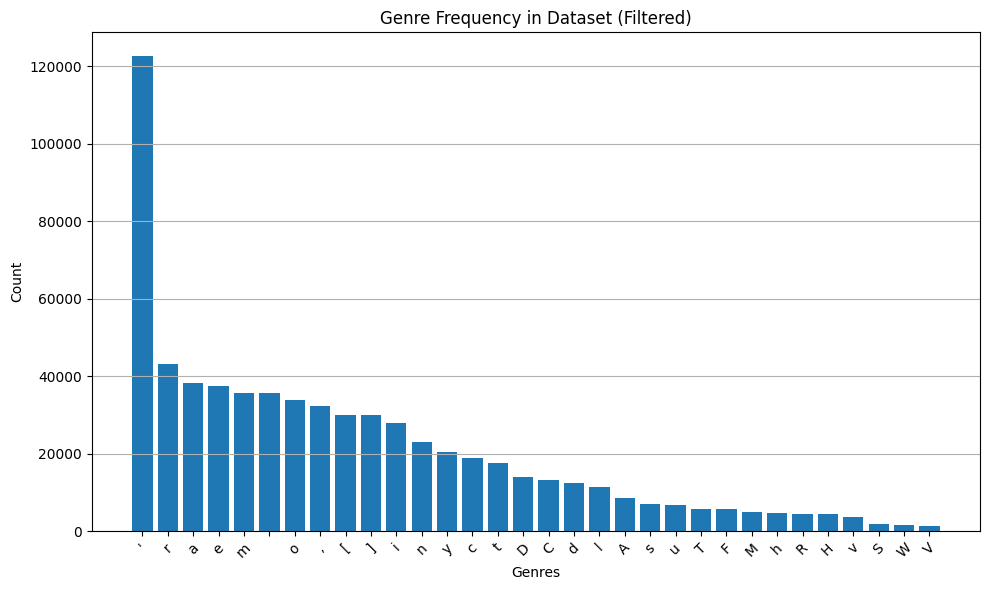

In [ ]:
dropped_genres = set(genre_df[genre_df['Count'] <= 10]['Genre'])


fdf['genres'] = fdf['genres'].apply(lambda genres: [g for g in genres if g not in dropped_genres])


genre_df = genre_df[genre_df['Count'] > 10]

fdf.to_csv("cleaned1.csv", index=False)


plt.figure(figsize=(10, 6))
plt.bar(genre_df['Genre'], genre_df['Count'])
plt.xlabel('Genres')
plt.ylabel('Count')
plt.title('Genre Frequency in Dataset (Filtered)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


In [ ]:

fdf.head(5)

,overview,genres,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,sample_weight
0,nikander rubbish collector would entrepreneur ...,"[[, ', C, o, m, e, d, y, ', ,, , ', D, r, a, ...",0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0.000137
1,four young friend taking shortcut en route loc...,"[[, ', A, c, t, i, o, n, ', ,, , ', C, r, i, ...",1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0.000251
2,nemo adventurous young clownfish unexpectedly ...,"[[, ', A, n, i, m, a, t, i, o, n, ', ,, , ', ...",0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0.000519
3,man low iq accomplished great thing life prese...,"[[, ', C, o, m, e, d, y, ', ,, , ', D, r, a, ...",0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0.000137
4,newspaper magnate charles foster kane taken mo...,"[[, ', M, y, s, t, e, r, y, ', ,, , ', D, r, ...",0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0.000350


In [ ]:
import pandas as pd
from collections import Counter

df = pd.read_csv("cleaned1.csv")


df['genres'] = df['genres'].apply(lambda x: eval(x) if isinstance(x, str) else x)

all_genres = [genre for sublist in df['genres'].dropna() for genre in sublist]
genre_counts = Counter(all_genres)


genre_to_weight = {genre: 1.0 / count for genre, count in genre_counts.items()}

def calculate_combination_weight(genres):
    if not genres or not isinstance(genres, list):
        return 1.0
    weights = [genre_to_weight.get(genre, 1.0) for genre in genres]
    return sum(weights) / len(weights)

df['sample_weight'] = df['genres'].apply(calculate_combination_weight)


unique_weights = df['sample_weight'].unique()
print("Unique sample weights:", unique_weights)

weight_counts = df['sample_weight'].value_counts()
print("\nSample Weight Distribution:")
print(weight_counts.head(10))

df.to_csv("cleaned1.csv", index=False)



Unique sample weights: [3.77198697e-05 4.63541846e-05 4.25019946e-05 ... 8.21742559e-05
 4.31430019e-05 7.56779316e-05]

Sample Weight Distribution:
sample_weight
0.000037    2872
0.000029    2469
0.000043    1396
0.000038    1114
0.000033    1069
0.000033     767
0.000074     738
0.000044     728
0.000042     711
0.000038     545
Name: count, dtype: int64


In [ ]:
import pandas as pd
from ast import literal_eval
from collections import Counter


df = pd.read_csv("/content/drive/MyDrive/movie_recommendation/tmdb_cleaned_final.csv")


df['genres'] = df['genres'].apply(literal_eval)


all_genres = [genre for sublist in df['genres'] for genre in sublist]


genre_counts = Counter(all_genres)


genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by="Count", ascending=False)

print(genre_df)


              Genre  Count
1             Drama  11762
0            Comedy   9961
5          Thriller   4554
2           Romance   4410
3            Action   4359
18           Horror   3385
4             Crime   3294
10        Adventure   2369
11      Documentary   2327
7            Family   2167
14            Music   2065
9   Science Fiction   1924
6         Animation   1735
12          Fantasy   1639
8           Mystery   1628
17         TV Movie   1266
16          History    981
13              War    854
15          Western    660


### Downloading the images

In [ ]:
import os
import time
import re
import requests
from PIL import Image
from io import BytesIO

API_KEY = "c92a10b9"
SAVE_DIR = "posters"
MAX_PAGES = 1000
MAX_IMAGES = 5500

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

def get_all_movie_titles():
    movie_titles = []
    page = 1

    while page <= MAX_PAGES and len(movie_titles) < MAX_IMAGES:
        url = f"http://www.omdbapi.com/?s=movie&type=movie&page={page}&apikey={API_KEY}"
        response = requests.get(url)
        data = response.json()

        if data.get('Response') == 'True':
            movie_titles.extend([movie['Title'] for movie in data['Search']])
            print(f"Fetched {len(movie_titles)} movies...")
        else:
            break

        page += 1
        time.sleep(1)

    return movie_titles[:MAX_IMAGES]

def get_movie_data(movie_title):
    url = f"http://www.omdbapi.com/?t={movie_title}&apikey={API_KEY}"
    response = requests.get(url)
    return response.json()

def sanitize_filename(filename):
    return re.sub(r'[\/:*?"<>|]', '_', filename)

def download_poster(poster_url, movie_title, save_dir=SAVE_DIR):
    try:
        safe_movie_title = sanitize_filename(movie_title)
        poster_path = os.path.join(save_dir, f"{safe_movie_title}.jpg")

        if os.path.exists(poster_path):
            print(f"Poster already exists for {movie_title}. Skipping.")
            return

        response = requests.get(poster_url)
        response.raise_for_status()

        img = Image.open(BytesIO(response.content))
        img.verify()
        img = Image.open(BytesIO(response.content))
        img.save(poster_path)

        print(f"Downloaded poster for {movie_title}.")
    except Exception as e:
        print(f"Failed to download poster for {movie_title}: {e}")

movie_titles = get_all_movie_titles()
print(f"Total movies fetched: {len(movie_titles)}")

downloaded_count = 0

for movie in movie_titles:
    if downloaded_count >= MAX_IMAGES:
        break

    data = get_movie_data(movie)

    if data.get('Response') == 'True':
        poster_url = data.get('Poster')
        if poster_url and poster_url != 'N/A':
            download_poster(poster_url, movie)
            downloaded_count += 1
        else:
            print(f"No poster found for {movie}.")
    else:
        print(f"No data found for {movie}.")

    time.sleep(1)

print(f"Total posters downloaded: {downloaded_count}")


Fetched 10 movies...
Fetched 20 movies...
Fetched 30 movies...
Fetched 40 movies...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import os


df = pd.read_csv("/content/drive/MyDrive/movie_recommendation/tmdb_cleaned.csv")


POSTER_DIR = "/content/drive/MyDrive/movie_recommendation/posters"

def clean_poster_filename(poster_path):

    return poster_path.split('/')[-1]


valid_poster_files = set(os.listdir(POSTER_DIR))


df['poster_path'] = df['poster_path'].apply(lambda x: clean_poster_filename(str(x)))
df = df[df['poster_path'].isin(valid_poster_files)]


print(f"Updated dataset shape after filtering posters: {df.shape}")


Updated dataset shape after filtering posters: (30016, 24)


In [ ]:

df.to_csv("tmdb_cleaned_final.csv", index=False)
print("Rows with missing posters dropped and dataset saved as tmdb_cleaned_final.csv")


Rows with missing posters dropped and dataset saved as tmdb_cleaned_final.csv


In [ ]:
poster_not_found_count = (df['poster_path'] == "Poster Not Found").sum()
print("Poster Not Found count:", poster_not_found_count)
print(len(df['poster_path']))

Poster Not Found count: 0
30016


In [ ]:
import pandas as pd
import os


df = pd.read_csv("/content/drive/MyDrive/movie_recommendation/tmdb_cleaned.csv")


POSTER_DIR = "/content/drive/MyDrive/movie_recommendation/posters"

available_posters = set(os.listdir(POSTER_DIR))

df['poster_filename'] = df['poster_path'].apply(lambda x: os.path.basename(str(x)))


missing_posters = df[~df['poster_filename'].isin(available_posters)]

print(f"Total missing posters: {len(missing_posters)}")
print("Missing poster filenames:")
print(missing_posters['poster_filename'].tolist())


Total missing posters: 0
Missing poster filenames:
[]


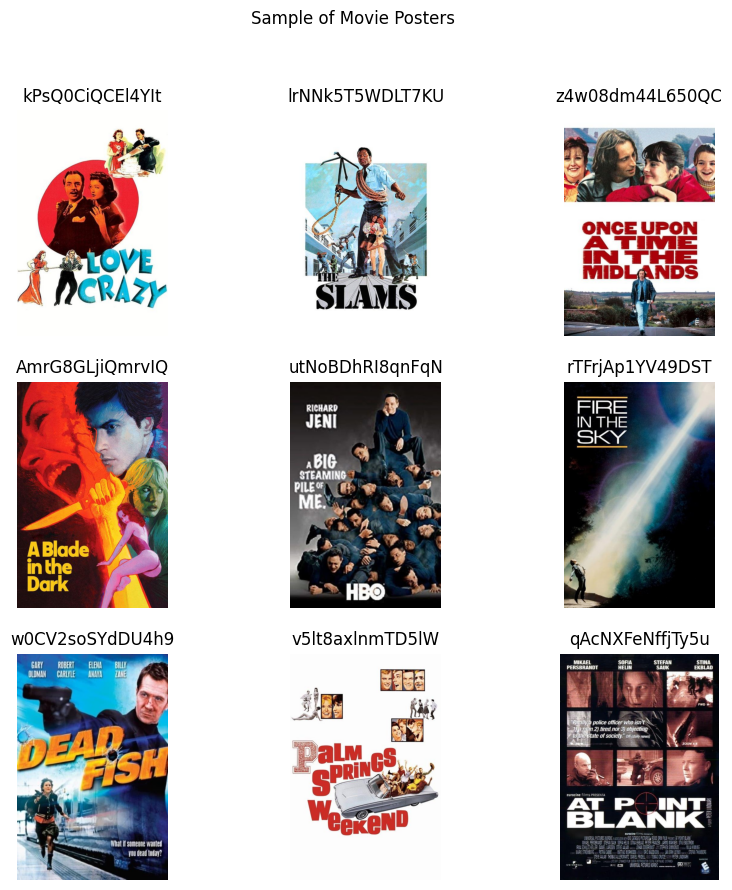

In [ ]:


import os
from PIL import Image
import matplotlib.pyplot as plt

POSTER_DIR = "/content/drive/MyDrive/movie_recommendation/posters"


if not os.path.exists(POSTER_DIR):
    print(f"Error: Directory '{POSTER_DIR}' not found.")
else:
    available_posters = [f for f in os.listdir(POSTER_DIR) if os.path.isfile(os.path.join(POSTER_DIR, f))]

    if not available_posters:
        print(f"Error: No poster files found in '{POSTER_DIR}'.")
    else:
        sample_files = random.sample(available_posters, min(9, len(available_posters)))

        plt.figure(figsize=(10, 10))
        for i, file in enumerate(sample_files):
            try:
                img_path = os.path.join(POSTER_DIR, file)
                img = Image.open(img_path)
                plt.subplot(3, 3, i + 1)
                plt.imshow(img)
                plt.title(file[:15])
                plt.axis("off")
            except Exception as e:
                print(f"Error loading poster {file}: {e}")

        plt.suptitle("Sample of Movie Posters")
        plt.show()


In [ ]:

df = pd.read_csv("/content/drive/MyDrive/movie_recommendation/tmdb_cleaned.csv")
df.head(5)

,title,overview,genres,poster_path,Action,Adventure,Animation,Comedy,Crime,Documentary,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,sample_weight
0,Shadows in Paradise,"Nikander, a rubbish collector and would-be ent...","['Comedy', 'Drama', 'Romance']",nj01hspawPof0mJmlgfjuLyJuRN.jpg,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0.000137
1,Judgment Night,"Four young friends, while taking a shortcut en...","['Action', 'Crime', 'Thriller']",3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0.000251
2,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...","['Animation', 'Family']",eHuGQ10FUzK1mdOY69wF5pGgEf5.jpg,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0.000519
3,Forrest Gump,A man with a low IQ has accomplished great thi...,"['Comedy', 'Drama', 'Romance']",arw2vcBveWOVZr6pxd9XTd1TdQa.jpg,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0.000137
4,Citizen Kane,Newspaper magnate Charles Foster Kane is taken...,"['Mystery', 'Drama']",sav0jxhqiH0bPr2vZFU0Kjt2nZL.jpg,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0.000350


In [ ]:


import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/movie_recommendation/tmdb_cleaned.csv")


selected_columns = ['title', 'overview', 'genres', 'poster_path', 'sample_weight']
fdf = df[selected_columns]
fdf.head(4)


,title,overview,genres,poster_path,sample_weight
0,Shadows in Paradise,"Nikander, a rubbish collector and would-be ent...","['Comedy', 'Drama', 'Romance']",nj01hspawPof0mJmlgfjuLyJuRN.jpg,0.000137
1,Judgment Night,"Four young friends, while taking a shortcut en...","['Action', 'Crime', 'Thriller']",3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg,0.000251
2,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...","['Animation', 'Family']",eHuGQ10FUzK1mdOY69wF5pGgEf5.jpg,0.000519
3,Forrest Gump,A man with a low IQ has accomplished great thi...,"['Comedy', 'Drama', 'Romance']",arw2vcBveWOVZr6pxd9XTd1TdQa.jpg,0.000137


In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(fdf, test_size=0.3, random_state=42)

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

print(type(train), type(test))


Train size: 21011
Test size: 9005
<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>


In [ ]:
train.to_csv("/content/drive/My Drive/movie_recommendation/new_evaluation/train_data.csv", index=False)
test.to_csv("/content/drive/My Drive/movie_recommendation/new_evaluation/test_data.csv", index=False)




In [ ]:
import pandas as pd
import os
import numpy as np
from PIL import Image
import pickle
from concurrent.futures import ThreadPoolExecutor, as_completed

train = pd.read_csv("/content/drive/My Drive/movie_recommendation/new_evaluation/train_data.csv")
max_samples = 21550
train = train.head(max_samples)

poster_dir = "/content/drive/MyDrive/movie_recommendation/posters"

movie_posters = [None] * len(train)
indices_to_drop = []

def process_image(idx_row):
    idx, row = idx_row
    img_path = os.path.join(poster_dir, str(row['poster_path']))
    try:
        img = Image.open(img_path).convert('RGB')
        img = img.resize((224, 224))
        return idx, np.array(img)
    except Exception as e:
        print(f"[{idx}] Error processing {img_path}: {e}")
        return idx, None

print("Starting image processing...")

with ThreadPoolExecutor(max_workers=16) as executor:
    futures = {executor.submit(process_image, item): i for i, item in enumerate(train.iterrows())}
    for i, future in enumerate(as_completed(futures)):
        idx, result = future.result()
        if result is not None:
            movie_posters[idx] = result
        else:
            indices_to_drop.append(idx)
        if i % 100 == 0:
            print(f"Processed {i}/{len(futures)}")

# Filter valid images
valid_indices = set(range(len(train))) - set(indices_to_drop)
movie_posters = [movie_posters[i] for i in valid_indices]
train = train.drop(indices_to_drop)

movie_posters_array = np.stack(movie_posters)
print(f"Shape of image array: {movie_posters_array.shape}")

train.to_csv("/content/drive/My Drive/movie_recommendation/new_evaluation/train_updated.csv", index=False)
with open('/content/drive/My Drive/movie_recommendation/movie_posters_data', 'wb') as f:
    pickle.dump(movie_posters_array, f)


Starting image processing...
Processed 0/21011
Processed 100/21011
Processed 200/21011
Processed 300/21011
Processed 400/21011
Processed 500/21011
Processed 600/21011
Processed 700/21011
Processed 800/21011
Processed 900/21011
Processed 1000/21011
Processed 1100/21011
Processed 1200/21011
Processed 1300/21011
Processed 1400/21011
Processed 1500/21011
Processed 1600/21011
Processed 1700/21011
Processed 1800/21011
Processed 1900/21011
Processed 2000/21011
Processed 2100/21011
Processed 2200/21011
Processed 2300/21011
Processed 2400/21011
Processed 2500/21011
Processed 2600/21011
Processed 2700/21011
Processed 2800/21011
Processed 2900/21011
Processed 3000/21011
Processed 3100/21011
Processed 3200/21011
Processed 3300/21011
Processed 3400/21011
Processed 3500/21011
Processed 3600/21011
Processed 3700/21011
Processed 3800/21011
Processed 3900/21011
Processed 4000/21011
Processed 4100/21011
Processed 4200/21011
Processed 4300/21011
Processed 4400/21011
Processed 4500/21011
Processed 4600/21

In [ ]:
import pandas as pd
import os
import numpy as np
from PIL import Image
import pickle
from concurrent.futures import ThreadPoolExecutor, as_completed


test = pd.read_csv("/content/drive/My Drive/movie_recommendation/new_evaluation/test_data.csv")
poster_dir = "/content/drive/MyDrive/movie_recommendation/posters"


test_movie_posters = [None] * len(test)
indices_to_drop = []


def process_image(idx_row):
    idx, row = idx_row
    img_path = os.path.join(poster_dir, str(row['poster_path']))
    try:
        img = Image.open(img_path).convert('RGB')
        img = img.resize((224, 224))
        return idx, np.array(img)
    except Exception as e:
        print(f"[{idx}] Error processing {img_path}: {e}")
        return idx, None

print("Starting multithreaded image processing...")


with ThreadPoolExecutor(max_workers=16) as executor:
    futures = {executor.submit(process_image, item): i for i, item in enumerate(test.iterrows())}
    for i, future in enumerate(as_completed(futures)):
        idx, result = future.result()
        if result is not None:
            test_movie_posters[idx] = result
        else:
            indices_to_drop.append(idx)
        if i % 100 == 0:
            print(f"Processed {i}/{len(futures)}")


valid_indices = set(range(len(test))) - set(indices_to_drop)
test_movie_posters = [test_movie_posters[i] for i in valid_indices]
test = test.drop(indices_to_drop)

test_movie_posters_array = np.stack(test_movie_posters)
print(f"Shape of test image array: {test_movie_posters_array.shape}")

test.to_csv("/content/drive/My Drive/movie_recommendation/new_evaluation/test_updated.csv", index=False)
with open('/content/drive/My Drive/movie_recommendation/test_movie_posters_data', 'wb') as f:
    pickle.dump(test_movie_posters_array, f)


Starting multithreaded image processing...
Processed 0/9005
Processed 100/9005
Processed 200/9005
Processed 300/9005
Processed 400/9005
Processed 500/9005
Processed 600/9005
Processed 700/9005
Processed 800/9005
Processed 900/9005
Processed 1000/9005
Processed 1100/9005
Processed 1200/9005
Processed 1300/9005
Processed 1400/9005
Processed 1500/9005
Processed 1600/9005
Processed 1700/9005
Processed 1800/9005
Processed 1900/9005
Processed 2000/9005
Processed 2100/9005
Processed 2200/9005
Processed 2300/9005
Processed 2400/9005
Processed 2500/9005
Processed 2600/9005
Processed 2700/9005
Processed 2800/9005
Processed 2900/9005
Processed 3000/9005
Processed 3100/9005
Processed 3200/9005
Processed 3300/9005
Processed 3400/9005
Processed 3500/9005
Processed 3600/9005
Processed 3700/9005
Processed 3800/9005
Processed 3900/9005
Processed 4000/9005
Processed 4100/9005
Processed 4200/9005
Processed 4300/9005
Processed 4400/9005
Processed 4500/9005
Processed 4600/9005
Processed 4700/9005
Processed